In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv('../data/matches.csv')
print("Dataset loaded successfully!")
print(f"Total matches: {len(df)}")

Dataset loaded successfully!
Total matches: 1095


In [50]:
df.head

<bound method NDFrame.head of            id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  2008-04-18       League      BB McCullum   
1      335983  2007/08  Chandigarh  2008-04-19       League       MEK Hussey   
2      335984  2007/08       Delhi  2008-04-19       League      MF Maharoof   
3      335985  2007/08      Mumbai  2008-04-20       League       MV Boucher   
4      335986  2007/08     Kolkata  2008-04-20       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  2024-05-19       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  2024-05-21  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  2024-05-22   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  2024-05-24  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  2024-05-26        Final         MA Starc   

         

In [51]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1095
Columns: 20


In [52]:
df.columns.tolist()

['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'method',
 'umpire1',
 'umpire2']

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [54]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [55]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [56]:
df['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [57]:
df['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [58]:
df['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Punjab Kings                    24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [59]:
df['result'].value_counts()

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

In [60]:
print(f"Total matches: {len(df)}")

Total matches: 1095


In [61]:
df['target_runs'].value_counts()

target_runs
172.0    21
166.0    21
165.0    20
188.0    20
163.0    19
         ..
66.0      1
104.0     1
58.0      1
231.0     1
242.0     1
Name: count, Length: 170, dtype: int64

In [62]:
# Remove no-result matches
df = df[df['winner'].notna()].reset_index(drop=True)
print(f"Matches after cleaning: {len(df)}")

Matches after cleaning: 1090


In [63]:
# Set plot style using matpotlib and seaborn.
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\rohan\AppData\Local\Temp\ipykernel_27584\3301531449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.index, y=win_counts.values, palette='YlOrRd_r')


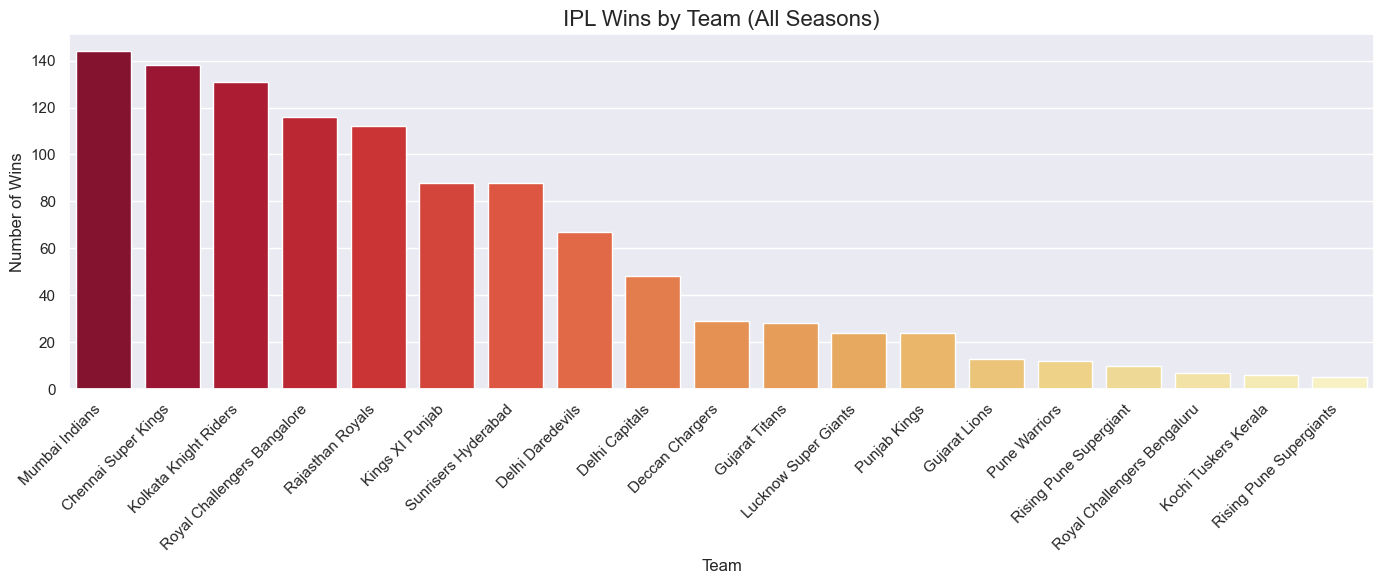

In [64]:
plt.figure(figsize=(14, 6))
win_counts = df['winner'].value_counts()
sns.barplot(x=win_counts.index, y=win_counts.values, palette='YlOrRd_r')
plt.title('IPL Wins by Team (All Seasons)', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

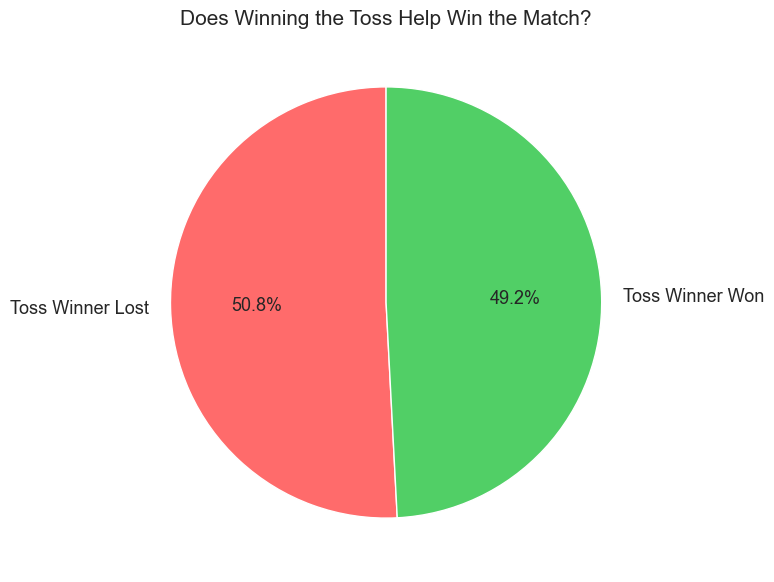

Toss winner won the match: 554 times (50.8%)


In [65]:
df['toss_match_win'] = df['toss_winner'] == df['winner']

toss_effect = df['toss_match_win'].value_counts()
labels = ['Toss Winner Lost', 'Toss Winner Won']
colors = ['#ff6b6b', '#51cf66']

plt.figure(figsize=(7, 7))
plt.pie(toss_effect.values, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
plt.title('Does Winning the Toss Help Win the Match?', fontsize=15)
plt.show()

print(f"Toss winner won the match: {toss_effect[True]} times ({toss_effect[True]/len(df)*100:.1f}%)")

C:\Users\rohan\AppData\Local\Temp\ipykernel_27584\74341722.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette='Blues_r')


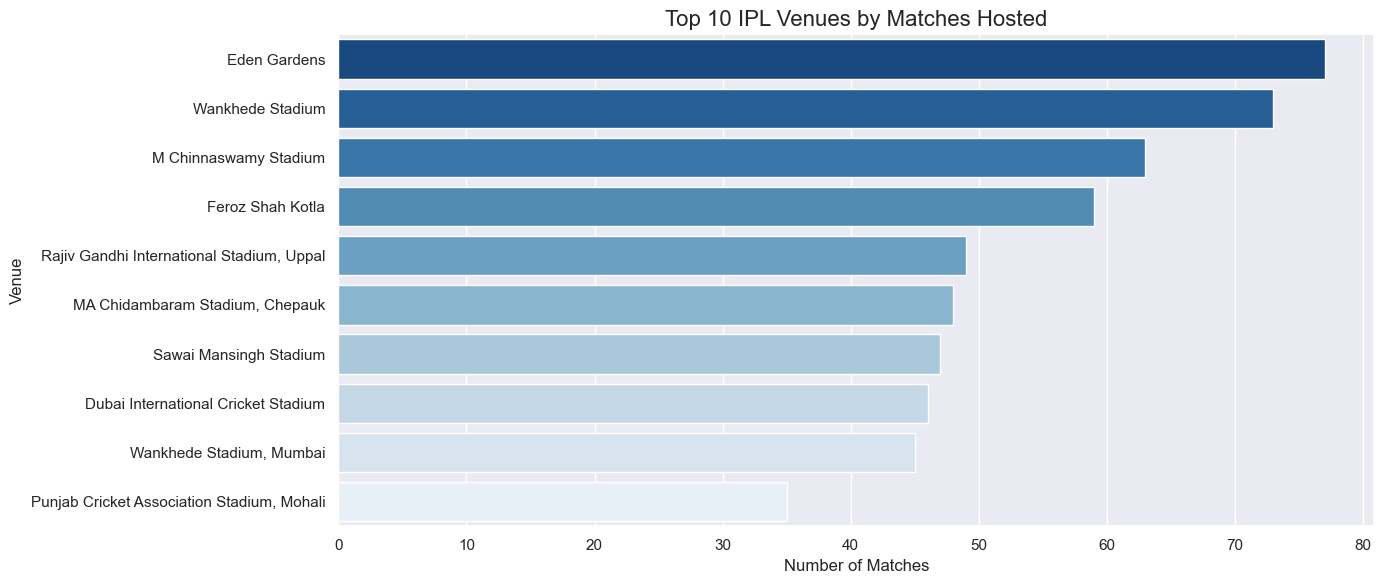

In [66]:
plt.figure(figsize=(14, 6))
top_venues = df['venue'].value_counts().head(10)
sns.barplot(x=top_venues.values, y=top_venues.index, palette='Blues_r')
plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=16)
plt.xlabel('Number of Matches', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.tight_layout()
plt.show()

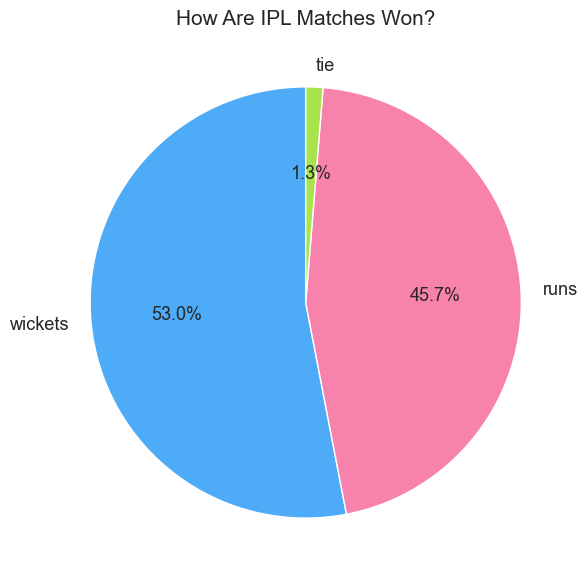

In [67]:
plt.figure(figsize=(7, 7))
result_counts = df['result'].value_counts()
colors = ['#4dabf7', '#f783ac', '#a9e34b']
plt.pie(result_counts.values, labels=result_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
plt.title('How Are IPL Matches Won?', fontsize=15)
plt.show()

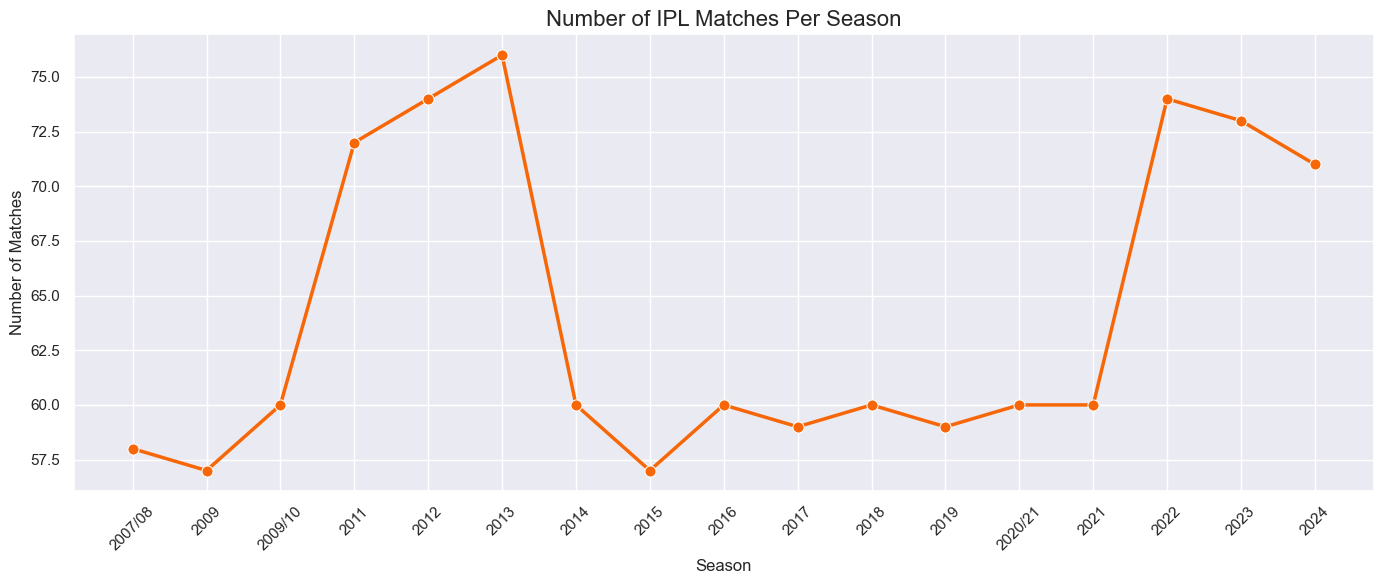

In [68]:
plt.figure(figsize=(14, 6))
season_counts = df['season'].value_counts().sort_index()
sns.lineplot(x=season_counts.index, y=season_counts.values,
             marker='o', color='#f76707', linewidth=2.5, markersize=8)
plt.title('Number of IPL Matches Per Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

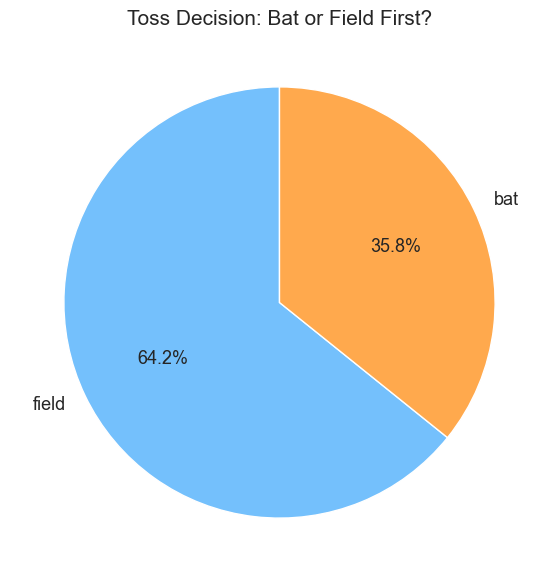

In [69]:
plt.figure(figsize=(7, 7))
toss_decision = df['toss_decision'].value_counts()
colors = ['#74c0fc', '#ffa94d']
plt.pie(toss_decision.values, labels=toss_decision.index, colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
plt.title('Toss Decision: Bat or Field First?', fontsize=15)
plt.show()

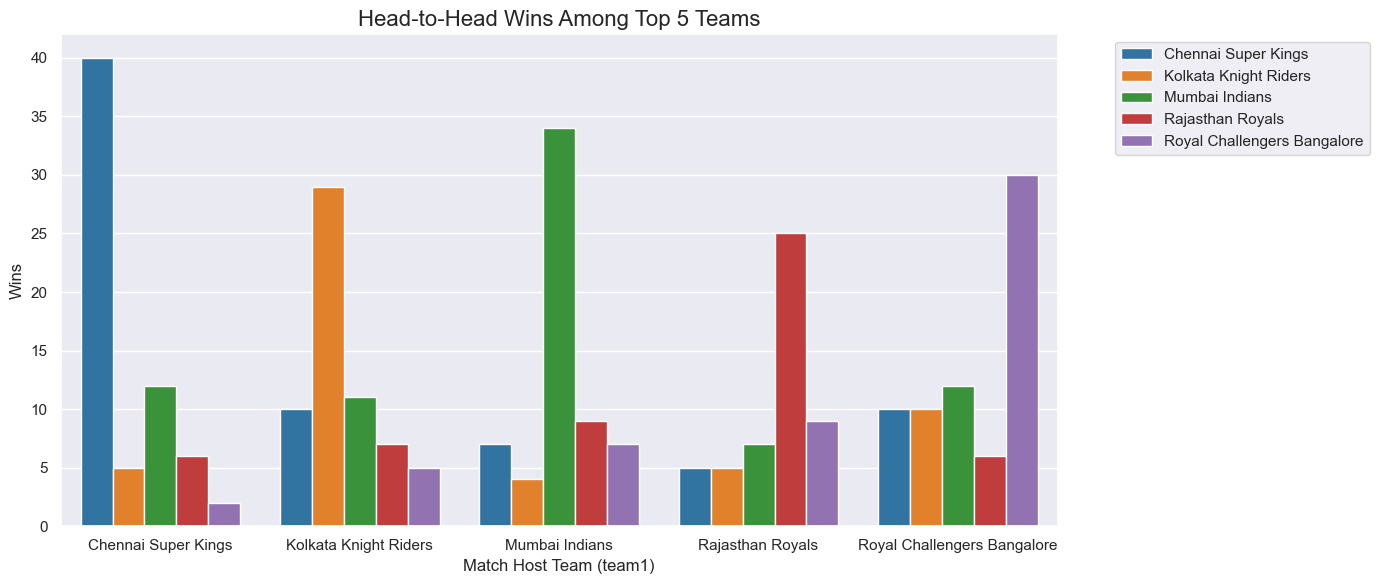

In [70]:
top5_teams = df['winner'].value_counts().head(5).index.tolist()

h2h = df[df['team1'].isin(top5_teams) & df['team2'].isin(top5_teams)]
h2h_wins = h2h.groupby(['team1', 'winner']).size().reset_index(name='wins')

plt.figure(figsize=(14, 6))
sns.barplot(data=h2h_wins, x='team1', y='wins', hue='winner', palette='tab10')
plt.title('Head-to-Head Wins Among Top 5 Teams', fontsize=16)
plt.xlabel('Match Host Team (team1)', fontsize=12)
plt.ylabel('Wins', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [71]:
#Cleaning the data and preparing it for thr ML model.


print(f"Total matches: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Total matches: 1090
Columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'toss_match_win']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,False


In [72]:
df.drop(['id', 'date', 'player_of_match', 'umpire1', 'umpire2',
         'result_margin', 'target_runs', 'target_overs',
         'method', 'super_over'], axis=1, inplace=True)

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['season', 'city', 'match_type', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'toss_match_win']


In [73]:
team_name_fix = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings'
}

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_name_fix)

print("Team names fixed!")
df['winner'].value_counts()

Team names fixed!


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Sunrisers Hyderabad            117
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [74]:
df['team1_win'] = (df['winner'] == df['team1']).astype(int)

print(f"Team1 won: {df['team1_win'].sum()} matches")
print(f"Team1 lost: {(df['team1_win'] == 0).sum()} matches")

Team1 won: 555 matches
Team1 lost: 535 matches


In [75]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

encode_cols = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city']

for col in encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done!")
df.head()

Encoding done!


,season,city,match_type,venue,team1,team2,toss_winner,toss_decision,winner,result,toss_match_win,team1_win
0,2007/08,2,League,23,12,5,12,1,Kolkata Knight Riders,runs,False,0
1,2007/08,7,League,40,9,0,0,0,Chennai Super Kings,runs,True,0
2,2007/08,10,League,16,1,10,10,0,Delhi Capitals,wickets,False,1
3,2007/08,26,League,55,7,12,7,0,Royal Challengers Bengaluru,wickets,False,0
4,2007/08,23,League,14,5,13,13,0,Kolkata Knight Riders,wickets,False,1


In [76]:
features = ['team1', 'team2', 'venue', 'city', 'toss_winner', 'toss_decision', 'season']

X = df[features]
y = df['team1_win']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1090, 7)
Target shape: (1090,)


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 872
Testing samples: 218


In [78]:
 print(df['season'].unique())

['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']


In [79]:
# Convert '2020/21' → '2020', '2007/08' → '2007' etc.
df['season'] = df['season'].astype(str).str[:4].astype(int)

print("Season fixed! Sample values:")
print(df['season'].unique())

Season fixed! Sample values:
[2007 2009 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]


In [84]:
import os
print(os.getcwd())  # shows where Jupyter is looking
print(os.listdir())  # shows what files are in that folder

C:\Users\rohan\OneDrive\Desktop\ipl predictions\notebook
['.ipynb_checkpoints', '.virtual_documents', 'anaconda_projects', 'ipl_analysis.ipynb']


In [85]:
import os

# Go one level up to the main project folder
print(os.listdir('..'))

['data', 'notebook']


In [86]:
df = pd.read_csv('../data/matches.csv')

In [87]:
df = df[df['winner'].notna()].reset_index(drop=True)


In [89]:
team_name_fix = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings'
}

In [90]:
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_name_fix)

In [91]:
df['season'] = df['season'].astype(str).str[:4].astype(int)
print("Seasons:", df['season'].unique())

Seasons: [2007 2009 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]


In [92]:
df['team1_win'] = (df['winner'] == df['team1']).astype(int)


In [93]:
from sklearn.preprocessing import LabelEncoder
encode_cols = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city']
for col in encode_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [94]:
features = ['team1', 'team2', 'venue', 'city', 'toss_winner', 'toss_decision', 'season']
X = df[features]
y = df['team1_win']

In [95]:
print("\nData types:")
print(X.dtypes)
print(f"\nAny nulls: {X.isnull().sum().sum()}")

# Step 9 - Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")


Data types:
team1            int32
team2            int32
venue            int32
city             int32
toss_winner      int32
toss_decision    int32
season           int32
dtype: object

Any nulls: 0

Train: 872, Test: 218


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 51.38%
Decision Tree: 49.08%
Random Forest: 47.71%


In [97]:
# Calculate each team's overall win rate
win_rate = {}
all_teams = pd.concat([df['team1'], df['team2']]).unique()

for team in all_teams:
    matches_played = len(df[(df['team1'] == team) | (df['team2'] == team)])
    matches_won = len(df[df['winner'] == team])
    win_rate[team] = matches_won / matches_played if matches_played > 0 else 0

print("Win rates calculated for", len(win_rate), "teams")

Win rates calculated for 14 teams


In [98]:
# Full rebuild with win rate feature
df = pd.read_csv('../data/matches.csv')
df = df[df['winner'].notna()].reset_index(drop=True)

# Fix team names
team_name_fix = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_name_fix)

# Fix season
df['season'] = df['season'].astype(str).str[:4].astype(int)

# Add win rate feature BEFORE encoding
all_teams = pd.concat([df['team1'], df['team2']]).unique()
win_rate = {}
for team in all_teams:
    played = len(df[(df['team1'] == team) | (df['team2'] == team)])
    won = len(df[df['winner'] == team])
    win_rate[team] = won / played if played > 0 else 0

df['team1_win_rate'] = df['team1'].map(win_rate)
df['team2_win_rate'] = df['team2'].map(win_rate)

# Create target
df['team1_win'] = (df['winner'] == df['team1']).astype(int)

# Encode
from sklearn.preprocessing import LabelEncoder
encode_cols = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city']
for col in encode_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# New features with win rate added
features = ['team1', 'team2', 'venue', 'city', 'toss_winner',
            'toss_decision', 'season', 'team1_win_rate', 'team2_win_rate']

X = df[features]
y = df['team1_win']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 53.67%
Decision Tree: 51.83%
Random Forest: 50.46%


C:\Users\rohan\AppData\Local\Temp\ipykernel_27584\1244527706.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


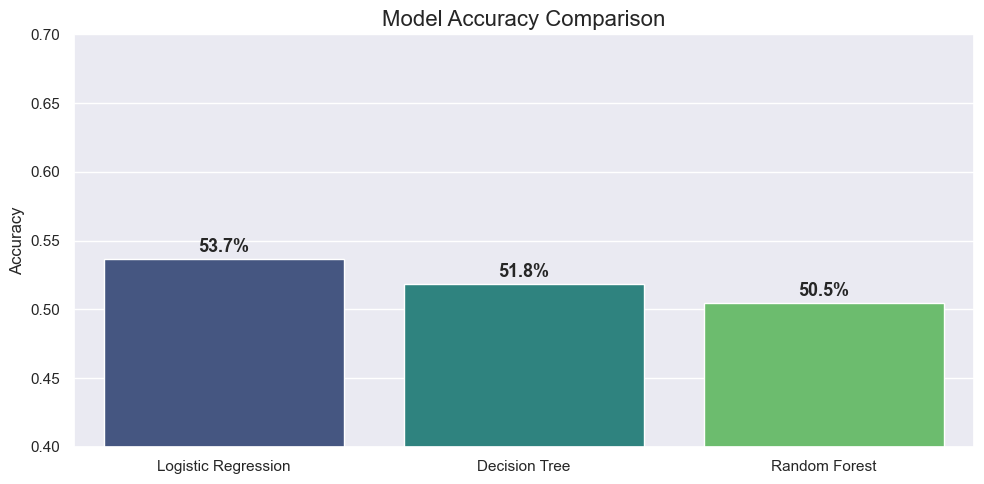

In [99]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.4, 0.7)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.005, f"{acc*100:.1f}%", ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

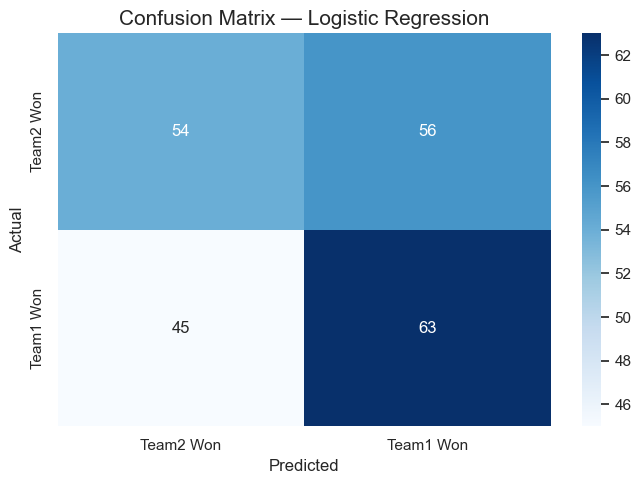

In [100]:
from sklearn.metrics import confusion_matrix, classification_report

rf_model = models['Logistic Regression']  # best model this time
rf_preds = rf_model.predict(X_test)

cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team2 Won', 'Team1 Won'],
            yticklabels=['Team2 Won', 'Team1 Won'])
plt.title('Confusion Matrix — Logistic Regression', fontsize=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\rohan\AppData\Local\Temp\ipykernel_27584\657315477.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='rocket')


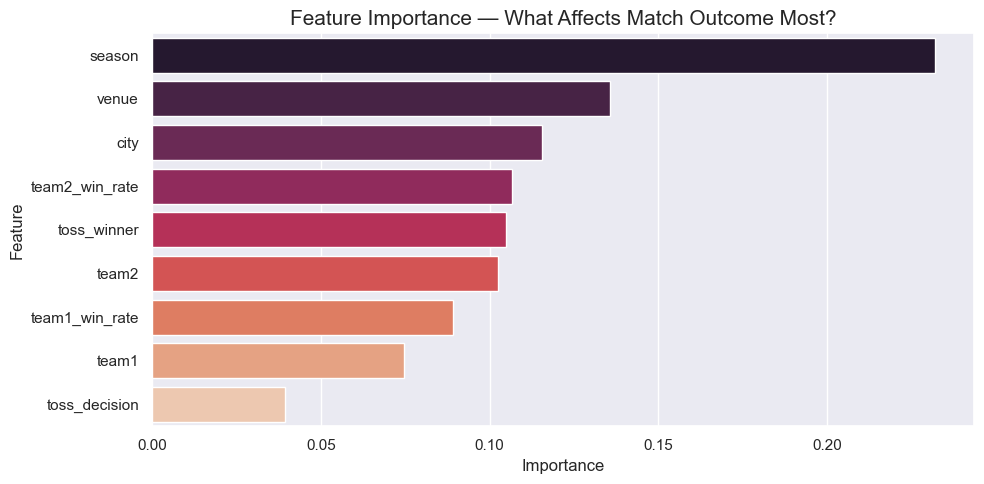

          Feature  Importance
6          season    0.231949
2           venue    0.135693
3            city    0.115492
8  team2_win_rate    0.106616
4     toss_winner    0.104932
1           team2    0.102386
7  team1_win_rate    0.089074
0           team1    0.074532
5   toss_decision    0.039326


In [101]:
rf_model2 = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model2.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='rocket')
plt.title('Feature Importance — What Affects Match Outcome Most?', fontsize=15)
plt.tight_layout()
plt.show()

print(feature_importance)

## 🏏 IPL Match Winner Prediction — Project Conclusion

### Project Summary
This project predicts IPL match winners using historical match data (2008–2024)
covering 1090 matches across all IPL seasons.

### Models Used
| Model | Accuracy |
|-------|----------|
| Logistic Regression | 53.67% |(Mostly correct)
| Decision Tree | 51.83% |
| Random Forest | 50.46% |

### Key Findings
- **Season** was the most important feature — different eras had different dominant teams
- **Team win rate** helped the model understand historical team strength
- **Toss winner** had surprisingly little impact on match outcome (~50/50)
- Most matches are won by wickets rather than runs

### Why Accuracy Is Moderate
IPL is genuinely unpredictable. Key factors like player form,
injuries, pitch conditions, and weather are not available in
the dataset. Even expert analysts struggle to predict IPL outcomes
consistently. A ~54% accuracy means the model is learning real patterns.

### What I Would Improve Next
- Add player-level statistics (top batsman, bowler form)
- Include pitch and weather data
- Use recent form (last 5 matches) instead of overall win rate
- Try advanced models like XGBoost or Neural Networks

### Tools & Libraries Used
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn